In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_source = pd.read_csv(
        "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/bin/new/private_pub_ref_panel/study_samples_1300_snp.vcf.gz",
        sep="\t",
        header=2242,
        compression="gzip",
        engine="pyarrow",
    )

df_source


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,3886_1_bwa.bam.sorted.bam,3842_1_bwa.bam.sorted.bam
0,24,1033,.,C,G,41.943800,.,VDB=7.59373e-10;SGB=-0.693146;RPB=0.18381;MQB=...,GT:PL,"0/1:75,0,121",./.:.
1,24,1131,.,A,T,58.000000,.,VDB=0.369009;SGB=-0.693147;RPB=0.51975;MQB=0.0...,GT:PL,"0/1:46,0,189","0/1:91,0,255"
2,24,1167,.,C,A,84.000000,.,VDB=0.239832;SGB=-0.693147;RPB=0.908493;MQB=0....,GT:PL,"0/1:91,0,218","0/1:117,0,247"
3,24,1226,.,G,A,91.000000,.,VDB=0.116768;SGB=-0.693147;RPB=4.92319e-06;MQB...,GT:PL,"0/1:124,0,255","0/1:103,0,255"
4,24,1261,.,A,C,222.000000,.,VDB=1.66821e-08;SGB=-0.693147;RPB=1.78322e-11;...,GT:PL,"0/1:255,0,177","0/1:255,0,133"
...,...,...,...,...,...,...,...,...,...,...,...
176964,24,62301956,.,T,A,225.000000,.,VDB=0.86172;SGB=-0.636426;RPB=1;MQB=1;MQSB=0.3...,GT:PL,"0/1:142,0,12","1/1:255,63,0"
176965,24,62302323,.,T,C,225.000000,.,VDB=0.0893345;SGB=-0.662043;MQSB=0.924584;MQ0F...,GT:PL,"1/1:186,27,0","1/1:255,69,0"
176966,24,62303916,.,C,T,225.000000,.,VDB=0.661628;SGB=-0.692067;RPB=1;MQB=1;MQSB=0....,GT:PL,"1/1:239,40,0","1/1:255,63,0"
176967,24,62304999,.,G,A,16.319500,.,VDB=0.22;SGB=-0.453602;RPB=0;MQB=0;BQB=0.5;MQ0...,GT:PL,"1/1:43,2,0",./.:.


In [180]:
# train_df = df_source.sample(frac=0.8, random_state=42)
# train_df = train_df.sort_values(['#CHROM', 'POS'])
# train_df

In [181]:
# train_df.to_csv("80-SNP.csv", sep="\t", index=False)

In [ ]:
df_random = pd.read_csv(
        "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/bin/new/private_pub_ref_panel/random_50.vcf.gz",
        sep="\t",
        header=2242,
        compression="gzip",
        engine="pyarrow",
    )

df_random

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,3886_1_bwa.bam.sorted.bam,3842_1_bwa.bam.sorted.bam
0,24,112601,.,T,C,222.000000,.,VDB=6.78141e-05;SGB=-0.686358;RPB=0.268812;MQB...,GT:PL,./.:.,"0/1:255,0,255"
1,24,163270,.,C,T,188.000000,.,VDB=0.617745;SGB=-0.676189;RPB=0.98813;MQB=0.9...,GT:PL,./.:.,"0/1:222,0,255"
2,24,300821,.,T,C,225.000000,.,VDB=0.940952;SGB=-0.689466;MQSB=0.861658;MQ0F=...,GT:PL,./.:.,"1/1:255,48,0"
3,24,335857,.,A,G,222.000000,.,VDB=0.0097835;SGB=-0.692352;RPB=0.130004;MQB=0...,GT:PL,./.:.,"0/1:255,0,255"
4,24,391651,.,A,G,225.000000,.,VDB=0.0531996;SGB=-0.688148;RPB=0.0704734;MQB=...,GT:PL,"0/1:255,0,255","1/1:255,57,0"
...,...,...,...,...,...,...,...,...,...,...,...
1110,24,61832911,.,G,T,225.000000,.,VDB=0.77123;SGB=-0.689466;MQSB=0.910176;MQ0F=0...,GT:PL,"1/1:255,48,0",./.:.
1111,24,61954180,.,A,G,225.000000,.,VDB=0.980452;SGB=-0.692352;MQSB=1;MQ0F=0;MQ=53...,GT:PL,./.:.,"1/1:255,63,0"
1112,24,61991351,.,G,A,225.000000,.,VDB=0.863196;SGB=-0.693079;MQSB=0.0228227;MQ0F...,GT:PL,"1/1:255,84,0","1/1:255,69,0"
1113,24,62039634,.,T,G,225.000000,.,VDB=0.571611;SGB=-0.69312;MQSB=0.924309;MQ0F=0...,GT:PL,"1/1:255,96,0",./.:.


In [183]:
df_result = pd.read_csv(
        "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/bin/usa_ref_my_intersect/usa_bulls_1376_intersection_imp.vcf.gz",
        sep="\t",
        header=8,
        compression="gzip",
        engine="pyarrow",
    )

df_result["DR2"] = df_result.apply(lambda row: float(row["INFO"][4:8]),axis=1)
df_result["MAF"] = df_result.apply(lambda row: min(float(row["INFO"][12:18]), 1- float(row["INFO"][12:18])),axis=1)



df_result

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,3886_1_bwa.bam.sorted.bam,3842_1_bwa.bam.sorted.bam,DR2,MAF
0,24,997,24_997_A_G,A,G,.,PASS,DR2=0.00;AF=0.0000;IMP,GT:DS,0|0:0,0|0:0,0.000000,0.000000
1,24,1025,24_1025_G_A,G,A,.,PASS,DR2=0.00;AF=0.0000;IMP,GT:DS,0|0:0,0|0:0,0.000000,0.000000
2,24,1027,24_1027_T_C,T,C,.,PASS,DR2=0.04;AF=0.0151;IMP,GT:DS,0|0:0.05,0|0:0.01,0.040000,0.015100
3,24,1033,24_1033_C_G,C,G,.,PASS,DR2=0.35;AF=0.7010;IMP,GT:DS,1|0:1.4,0|1:1.4,0.350000,0.299000
4,24,1034,24_1034_A_T,A,T,.,PASS,DR2=0.00;AF=0.0000;IMP,GT:DS,0|0:0,0|0:0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1580092,24,62305516,24_62305516_G_A,G,A,.,PASS,DR2=0.69;AF=0.1908;IMP,GT:DS,0|0:0,0|1:0.76,0.690000,0.190800
1580093,24,62305655,24_62305655_T_A,T,A,.,PASS,DR2=0.00;AF=0.0000;IMP,GT:DS,0|0:0,0|0:0,0.000000,0.000000
1580094,24,62305719,24_62305719_A_T,A,T,.,PASS,DR2=0.00;AF=0.0000;IMP,GT:DS,0|0:0,0|0:0,0.000000,0.000000
1580095,24,62305805,24_62305805_G_C,G,C,.,PASS,DR2=0.09;AF=0.0912;IMP,GT:DS,0|0:0.11,0|0:0.25,0.090000,0.091200


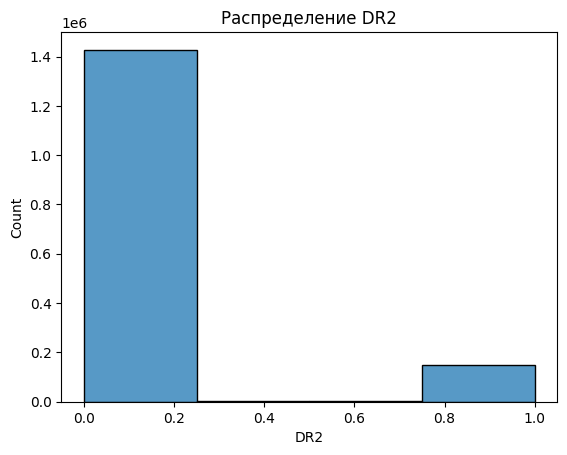

In [184]:
sns.histplot(data=df_result, x='DR2', bins=4)
plt.title('Распределение DR2')
plt.show()

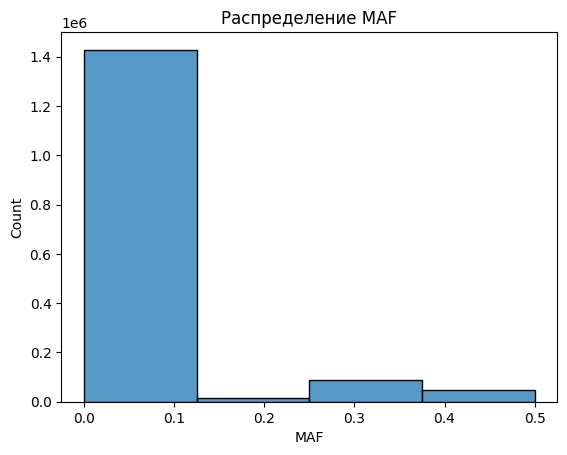

In [185]:
sns.histplot(data=df_result, x='MAF', bins=4)
plt.title('Распределение MAF')
plt.show()

In [186]:
pd.set_option('display.float_format', '{:.6f}'.format)  # для count без десятичных
result = df_result['DR2'].describe()
print(result)

count   1580097.000000
mean          0.094936
std           0.290588
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: DR2, dtype: float64


In [187]:
stats = df_result['MAF'].describe()
stats['count'] = int(stats['count'])
print(stats)

count   1580097.000000
mean          0.031606
std           0.102694
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.500000
Name: MAF, dtype: float64


In [188]:
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
labels = ["<0.01", "0.01-0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", ">0.3"]

df_result["MAF_bin"] = pd.cut(
    df_result["MAF"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


summary = df_result.groupby("MAF_bin").agg(
    total_SNP=("DR2", "count"),
    mean_DR2=("DR2", "mean"),
    high_quality=("DR2", lambda x: (x > 0.7).sum())
)

summary["percent_high"] = summary["high_quality"] / summary["total_SNP"] * 100

summary

/tmp/ipykernel_1485383/1841698191.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_result.groupby("MAF_bin").agg(


,total_SNP,mean_DR2,high_quality,percent_high
MAF_bin,,,,
<0.01,1422064,0.000058,0,0.000000
0.01-0.05,4169,0.047035,0,0.000000
0.05-0.1,1549,0.182918,0,0.000000
0.1-0.2,1580,0.443139,110,6.962025
0.2-0.3,102021,0.992223,101764,99.748091
>0.3,48714,0.975458,47627,97.768609


In [189]:
# df_pub = pd.read_csv(
#         "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/bin/new/private_pub_ref_panel/random_200_imp_pub.vcf.gz",
#         sep="\t",
#         header=8,
#         compression="gzip",
#         engine="pyarrow",
#     )

# df_pub

In [190]:
# df_pub.columns[9:] # Берём только колонки с генотипами

In [191]:
# df_pub - публичная реф панель
# df_result - своя реф панель

df = pd.merge(df_result, df_source, on="POS")


df

,#CHROM_x,POS,ID_x,REF_x,ALT_x,QUAL_x,FILTER_x,INFO_x,FORMAT_x,3886_1_bwa.bam.sorted.bam_x,...,#CHROM_y,ID_y,REF_y,ALT_y,QUAL_y,FILTER_y,INFO_y,FORMAT_y,3886_1_bwa.bam.sorted.bam_y,3842_1_bwa.bam.sorted.bam_y
0,24,1033,24_1033_C_G,C,G,.,PASS,DR2=0.35;AF=0.7010;IMP,GT:DS,1|0:1.4,...,24,.,C,G,41.943800,.,VDB=7.59373e-10;SGB=-0.693146;RPB=0.18381;MQB=...,GT:PL,"0/1:75,0,121",./.:.
1,24,1131,24_1131_A_T,A,T,.,PASS,DR2=0.15;AF=0.0650;IMP,GT:DS,0|0:0.23,...,24,.,A,T,58.000000,.,VDB=0.369009;SGB=-0.693147;RPB=0.51975;MQB=0.0...,GT:PL,"0/1:46,0,189","0/1:91,0,255"
2,24,1167,24_1167_C_A,C,A,.,PASS,DR2=0.23;AF=0.7946;IMP,GT:DS,1|1:1.6,...,24,.,C,A,84.000000,.,VDB=0.239832;SGB=-0.693147;RPB=0.908493;MQB=0....,GT:PL,"0/1:91,0,218","0/1:117,0,247"
3,24,1226,24_1226_G_A,G,A,.,PASS,DR2=0.46;AF=0.5030;IMP,GT:DS,1|0:1.41,...,24,.,G,A,91.000000,.,VDB=0.116768;SGB=-0.693147;RPB=4.92319e-06;MQB...,GT:PL,"0/1:124,0,255","0/1:103,0,255"
4,24,1261,24_1261_A_C,A,C,.,PASS,DR2=0.46;AF=0.5012;IMP,GT:DS,1|0:1.41,...,24,.,A,C,222.000000,.,VDB=1.66821e-08;SGB=-0.693147;RPB=1.78322e-11;...,GT:PL,"0/1:255,0,177","0/1:255,0,133"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176964,24,62301956,24_62301956_T_A,T,A,.,PASS,DR2=0.03;AF=0.9457;IMP,GT:DS,1|1:1.88,...,24,.,T,A,225.000000,.,VDB=0.86172;SGB=-0.636426;RPB=1;MQB=1;MQSB=0.3...,GT:PL,"0/1:142,0,12","1/1:255,63,0"
176965,24,62302323,24_62302323_T_C,T,C,.,PASS,DR2=0.00;AF=1.0000;IMP,GT:DS,1|1:2,...,24,.,T,C,225.000000,.,VDB=0.0893345;SGB=-0.662043;MQSB=0.924584;MQ0F...,GT:PL,"1/1:186,27,0","1/1:255,69,0"
176966,24,62303916,24_62303916_C_T,C,T,.,PASS,DR2=0.53;AF=0.7254;IMP,GT:DS,1|1:1.82,...,24,.,C,T,225.000000,.,VDB=0.661628;SGB=-0.692067;RPB=1;MQB=1;MQSB=0....,GT:PL,"1/1:239,40,0","1/1:255,63,0"
176967,24,62304999,24_62304999_G_A,G,A,.,PASS,DR2=0.62;AF=0.7799;IMP,GT:DS,1|1:1.94,...,24,.,G,A,16.319500,.,VDB=0.22;SGB=-0.453602;RPB=0;MQB=0;BQB=0.5;MQ0...,GT:PL,"1/1:43,2,0",./.:.


In [192]:
df["DR2"].describe()

count   176969.000000
mean         0.810404
std          0.380002
min          0.000000
25%          0.970000
50%          1.000000
75%          1.000000
max          1.000000
Name: DR2, dtype: float64

In [193]:
df["MAF"].describe()

count   176969.000000
mean         0.270023
std          0.162711
min          0.000000
25%          0.249900
50%          0.250000
75%          0.467100
max          0.500000
Name: MAF, dtype: float64

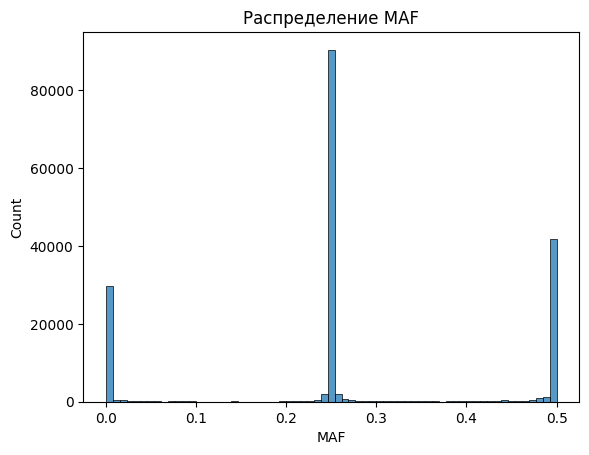

In [194]:


sns.histplot(data=df, x='MAF')
plt.title('Распределение MAF')
plt.show()

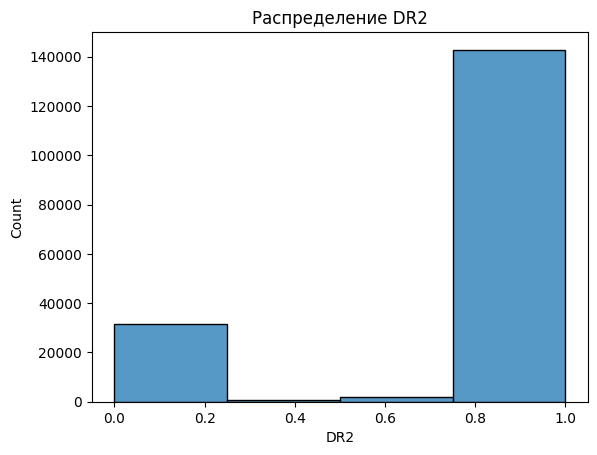

In [195]:
sns.histplot(data=df, x='DR2', bins=4)
plt.title('Распределение DR2')
plt.show()

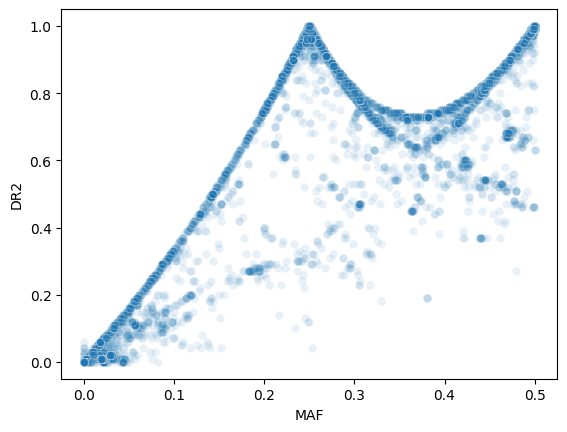

In [196]:
sns.scatterplot(data=df, x="MAF", y="DR2", alpha=0.1)
plt.show()

In [197]:
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
labels = ["<0.01", "0.01-0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", ">0.3"]

df["MAF_bin"] = pd.cut(
    df_result["MAF"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


summary = df.groupby("MAF_bin").agg(
    total_SNP=("DR2", "count"),
    mean_DR2=("DR2", "mean"),
    high_quality=("DR2", lambda x: (x > 0.7).sum())
)

summary["percent_high"] = summary["high_quality"] / summary["total_SNP"] * 100

summary

/tmp/ipykernel_1485383/14496468.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("MAF_bin").agg(


,total_SNP,mean_DR2,high_quality,percent_high
MAF_bin,,,,
<0.01,158351,0.809043,128279,81.009277
0.01-0.05,214,0.788411,167,78.037383
0.05-0.1,27,0.840000,22,81.481481
0.1-0.2,85,0.793882,68,80.000000
0.2-0.3,13737,0.816447,11236,81.793696
>0.3,4555,0.840681,3840,84.302964


In [198]:
df

,#CHROM_x,POS,ID_x,REF_x,ALT_x,QUAL_x,FILTER_x,INFO_x,FORMAT_x,3886_1_bwa.bam.sorted.bam_x,...,#CHROM_y,ID_y,REF_y,ALT_y,QUAL_y,FILTER_y,INFO_y,FORMAT_y,3886_1_bwa.bam.sorted.bam_y,3842_1_bwa.bam.sorted.bam_y
0,24,1033,24_1033_C_G,C,G,.,PASS,DR2=0.35;AF=0.7010;IMP,GT:DS,1|0:1.4,...,24,.,C,G,41.943800,.,VDB=7.59373e-10;SGB=-0.693146;RPB=0.18381;MQB=...,GT:PL,"0/1:75,0,121",./.:.
1,24,1131,24_1131_A_T,A,T,.,PASS,DR2=0.15;AF=0.0650;IMP,GT:DS,0|0:0.23,...,24,.,A,T,58.000000,.,VDB=0.369009;SGB=-0.693147;RPB=0.51975;MQB=0.0...,GT:PL,"0/1:46,0,189","0/1:91,0,255"
2,24,1167,24_1167_C_A,C,A,.,PASS,DR2=0.23;AF=0.7946;IMP,GT:DS,1|1:1.6,...,24,.,C,A,84.000000,.,VDB=0.239832;SGB=-0.693147;RPB=0.908493;MQB=0....,GT:PL,"0/1:91,0,218","0/1:117,0,247"
3,24,1226,24_1226_G_A,G,A,.,PASS,DR2=0.46;AF=0.5030;IMP,GT:DS,1|0:1.41,...,24,.,G,A,91.000000,.,VDB=0.116768;SGB=-0.693147;RPB=4.92319e-06;MQB...,GT:PL,"0/1:124,0,255","0/1:103,0,255"
4,24,1261,24_1261_A_C,A,C,.,PASS,DR2=0.46;AF=0.5012;IMP,GT:DS,1|0:1.41,...,24,.,A,C,222.000000,.,VDB=1.66821e-08;SGB=-0.693147;RPB=1.78322e-11;...,GT:PL,"0/1:255,0,177","0/1:255,0,133"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176964,24,62301956,24_62301956_T_A,T,A,.,PASS,DR2=0.03;AF=0.9457;IMP,GT:DS,1|1:1.88,...,24,.,T,A,225.000000,.,VDB=0.86172;SGB=-0.636426;RPB=1;MQB=1;MQSB=0.3...,GT:PL,"0/1:142,0,12","1/1:255,63,0"
176965,24,62302323,24_62302323_T_C,T,C,.,PASS,DR2=0.00;AF=1.0000;IMP,GT:DS,1|1:2,...,24,.,T,C,225.000000,.,VDB=0.0893345;SGB=-0.662043;MQSB=0.924584;MQ0F...,GT:PL,"1/1:186,27,0","1/1:255,69,0"
176966,24,62303916,24_62303916_C_T,C,T,.,PASS,DR2=0.53;AF=0.7254;IMP,GT:DS,1|1:1.82,...,24,.,C,T,225.000000,.,VDB=0.661628;SGB=-0.692067;RPB=1;MQB=1;MQSB=0....,GT:PL,"1/1:239,40,0","1/1:255,63,0"
176967,24,62304999,24_62304999_G_A,G,A,.,PASS,DR2=0.62;AF=0.7799;IMP,GT:DS,1|1:1.94,...,24,.,G,A,16.319500,.,VDB=0.22;SGB=-0.453602;RPB=0;MQB=0;BQB=0.5;MQ0...,GT:PL,"1/1:43,2,0",./.:.


In [199]:
df_for_an = df[df["INFO_x"].str.split(";").str[-1] != "IMP"]

df_for_an = df_for_an[df_for_an["3886_1_bwa.bam.sorted.bam_y"].str[0:3] != "./."]

df_for_an = df_for_an[df_for_an["3842_1_bwa.bam.sorted.bam_y"].str[0:3] != "./."]

df_for_an = df_for_an[df_for_an.MAF <= 0.01]

df_for_an = df_for_an[df_for_an.DR2 <= 0.3]

In [200]:
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
labels = ["<0.01", "0.01-0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", ">0.3"]

df_for_an["MAF_bin"] = pd.cut(
    df_result["MAF"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


summary = df_for_an.groupby("MAF_bin").agg(
    total_SNP=("DR2", "count"),
    mean_DR2=("DR2", "mean"),
    high_quality=("DR2", lambda x: (x > 0.7).sum())
)

summary["percent_high"] = summary["high_quality"] / summary["total_SNP"] * 100

summary

/tmp/ipykernel_1485383/364406652.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_for_an.groupby("MAF_bin").agg(


,total_SNP,mean_DR2,high_quality,percent_high
MAF_bin,,,,
<0.01,202,0.000000,0,0.000000
0.01-0.05,0,NaN,0,NaN
0.05-0.1,0,NaN,0,NaN
0.1-0.2,0,NaN,0,NaN
0.2-0.3,23,0.000000,0,0.000000
>0.3,5,0.000000,0,0.000000


In [201]:
df_for_an["DR2"].describe()

count   230.000000
mean      0.000000
std       0.000000
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.000000
Name: DR2, dtype: float64

In [202]:
df_for_an

,#CHROM_x,POS,ID_x,REF_x,ALT_x,QUAL_x,FILTER_x,INFO_x,FORMAT_x,3886_1_bwa.bam.sorted.bam_x,...,#CHROM_y,ID_y,REF_y,ALT_y,QUAL_y,FILTER_y,INFO_y,FORMAT_y,3886_1_bwa.bam.sorted.bam_y,3842_1_bwa.bam.sorted.bam_y
622,24,520222,24_520222_A_G,A,G,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,A,G,228.000000,.,VDB=0.248525;SGB=-0.690438;RPB=1;MQB=1;MQSB=1;...,GT:PL,"1/1:255,22,0","1/1:255,81,0"
2220,24,1271033,24_1271033_T_C,T,C,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,T,C,225.000000,.,VDB=0.251785;SGB=-0.693132;MQSB=0.841601;MQ0F=...,GT:PL,"1/1:255,102,0","1/1:255,87,0"
2531,24,1346177,24_1346177_T_C,T,C,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,T,C,225.000000,.,VDB=0.415989;SGB=-0.693021;MQSB=0.874386;MQ0F=...,GT:PL,"1/1:255,81,0","1/1:255,90,0"
6223,24,2274958,24_2274958_A_G,A,G,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,A,G,225.000000,.,VDB=0.924005;SGB=-0.692562;MQSB=0.635848;MQ0F=...,GT:PL,"1/1:255,66,0","1/1:255,69,0"
8234,24,2953070,24_2953070_A_C,A,C,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,A,C,225.000000,.,VDB=0.296277;SGB=-0.692067;MQSB=0.97436;MQ0F=0...,GT:PL,"1/1:255,60,0","1/1:255,42,0"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172662,24,61218781,24_61218781_T_C,T,C,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,T,C,225.000000,.,VDB=0.461294;SGB=-0.69168;MQSB=0.809572;MQ0F=0...,GT:PL,"1/1:255,54,0","1/1:255,42,0"
173213,24,61402755,24_61402755_C_A,C,A,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,C,A,228.000000,.,VDB=0.568278;SGB=-0.693136;RPB=1;MQB=1;MQSB=0....,GT:PL,"1/1:255,81,0","1/1:255,78,0"
173238,24,61413512,24_61413512_T_C,T,C,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,T,C,228.000000,.,VDB=0.748228;SGB=-0.692067;RPB=1;MQB=1;MQSB=0....,GT:PL,"1/1:255,36,0","1/1:255,72,0"
173549,24,61534805,24_61534805_G_C,G,C,.,PASS,DR2=0.00;AF=1.0000,GT:DS,1|1:2,...,24,.,G,C,225.000000,.,VDB=0.431509;SGB=-0.590765;MQSB=1;MQ0F=0;MQ=41...,GT:PL,"1/1:110,15,0","1/1:255,42,0"


In [203]:
df_for_an.columns

Index(['#CHROM_x', 'POS', 'ID_x', 'REF_x', 'ALT_x', 'QUAL_x', 'FILTER_x',
       'INFO_x', 'FORMAT_x', '3886_1_bwa.bam.sorted.bam_x',
       '3842_1_bwa.bam.sorted.bam_x', 'DR2', 'MAF', 'MAF_bin', '#CHROM_y',
       'ID_y', 'REF_y', 'ALT_y', 'QUAL_y', 'FILTER_y', 'INFO_y', 'FORMAT_y',
       '3886_1_bwa.bam.sorted.bam_y', '3842_1_bwa.bam.sorted.bam_y'],
      dtype='object')

In [204]:
def create_is_correct(row, colummn_gen):
    # print(row["HORUS003910309615_x"])
    imputed_non_phased = row[f"{colummn_gen}_x"][0:3].split("|")
    imputed_non_phased = "/".join(list(sorted(imputed_non_phased)))
    non_phased = row[f"{colummn_gen}_y"][0:3]
    if imputed_non_phased == non_phased:
        return True
    else:
        return False


all = 0
correct_imput = 0


for i in [i[0:-2] for i in df_for_an.columns if i.find("bam.sorted.bam_y") != -1]:
    is_correct = df_for_an.apply(lambda row: create_is_correct(row, i), axis = 1)
    all += len(is_correct[is_correct == True]) + len(is_correct[is_correct == False])
    correct_imput += len(is_correct[is_correct == True])



print(f"Импутация корректно восстановила {round((correct_imput/all)*100)}%")

# Причём оишбки это ./., т.е есть шанс, что и их оно угадало правильно, а чип просто ошибся

Импутация корректно восстановила 100%


In [205]:
correct_imput

460

In [206]:
all

460

In [207]:
is_correct

622       True
2220      True
2531      True
6223      True
8234      True
          ... 
172662    True
173213    True
173238    True
173549    True
175357    True
Length: 230, dtype: bool